# Hold-out Station Split

**Run this notebook ONCE before any model training.**

Selects a fixed 20% of stations as a hold-out test set, stratified by elevation zone.
Saves station IDs to `outputs/holdout_station_ids.json` — commit this file to git
so the split is reproducible without relying on a random seed.

After this file exists, `ReKISSource.load()` automatically excludes these stations
from all models (kriging, LightGBM) unless called with `exclude_holdout=False`.

**DO NOT re-run this notebook** after committing the JSON — it would change the split.

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

ROOT = Path('..').resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
from thesis.config import Config
from thesis.data.registry import DataRegistry

HOLDOUT_FRAC = 0.20
RANDOM_SEED  = 42
OUT_PATH     = ROOT / 'outputs' / 'holdout_station_ids.json'

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f'Working directory: {Path.cwd()}')
print(f'Output: {OUT_PATH}')

Working directory: /Users/etomengoi/Desktop/precip_interpolation_thesis
Output: /Users/etomengoi/Desktop/precip_interpolation_thesis/outputs/holdout_station_ids.json


In [2]:
if OUT_PATH.exists():
    existing = json.loads(OUT_PATH.read_text())
    print(f'WARNING: {OUT_PATH} already exists with {len(existing)} stations.')
    print('Do NOT re-run — the split is already fixed. Showing existing split stats below.')
    ALREADY_EXISTS = True
else:
    print('No existing split found — will generate now.')
    ALREADY_EXISTS = False

No existing split found — will generate now.


In [3]:
cfg      = Config()
registry = DataRegistry.from_config(cfg)

# Load ALL stations — bypass any existing holdout filter
all_raw = registry.stations.load(cfg.date_start, cfg.date_end, exclude_holdout=False)

station_meta = (
    all_raw.drop_duplicates('station_id')
    [['station_id', 'elevation_m']]
    .reset_index(drop=True)
)

n_nan = station_meta['elevation_m'].isna().sum()
n_neg = (station_meta['elevation_m'] < 0).sum()
if n_nan or n_neg:
    print(f'Note: {n_nan} NaN and {n_neg} negative elevation(s) — clipped to 0 for stratification')
station_meta['elevation_m'] = station_meta['elevation_m'].fillna(0).clip(lower=0)

# Elevation zones — same bins as k-fold CV
bins   = [0, 250, 500, 9999]
labels = ['plains', 'hills', 'mountains']
station_meta['elev_zone'] = pd.cut(
    station_meta['elevation_m'], bins=bins, labels=labels, right=False
).astype(str)

print(f'Total stations: {len(station_meta)}')
print(station_meta['elev_zone'].value_counts().sort_index())

Note: 0 NaN and 2 negative elevation(s) — clipped to 0 for stratification
Total stations: 2458
elev_zone
hills         665
mountains     264
plains       1529
Name: count, dtype: int64


In [4]:
if not ALREADY_EXISTS:
    sss = StratifiedShuffleSplit(n_splits=1, test_size=HOLDOUT_FRAC, random_state=RANDOM_SEED)
    train_idx, test_idx = next(sss.split(station_meta, station_meta['elev_zone']))

    holdout_ids = sorted(station_meta.iloc[test_idx]['station_id'].tolist())
    train_ids   = sorted(station_meta.iloc[train_idx]['station_id'].tolist())

    OUT_PATH.write_text(json.dumps(holdout_ids, indent=2))
    print(f'Saved {len(holdout_ids)} hold-out station IDs → {OUT_PATH}')
    print(f'Training pool: {len(train_ids)} stations')
else:
    holdout_ids = json.loads(OUT_PATH.read_text())
    train_ids   = [s for s in station_meta['station_id'] if s not in set(holdout_ids)]
    print(f'Using existing split: {len(holdout_ids)} hold-out, {len(train_ids)} train')

Saved 492 hold-out station IDs → /Users/etomengoi/Desktop/precip_interpolation_thesis/outputs/holdout_station_ids.json
Training pool: 1966 stations


In [5]:
# Verify stratification
holdout_set = set(holdout_ids)
holdout_meta = station_meta[station_meta['station_id'].isin(holdout_set)]
train_meta   = station_meta[~station_meta['station_id'].isin(holdout_set)]

print('Hold-out fraction by elevation zone:')
for zone in labels:
    n_total   = (station_meta['elev_zone'] == zone).sum()
    n_holdout = (holdout_meta['elev_zone'] == zone).sum()
    print(f'  {zone:<12s}  {n_holdout:4d} / {n_total:4d}  ({n_holdout/n_total*100:.1f}%)')

print(f'\nOverall:  {len(holdout_ids):4d} / {len(station_meta):4d}  ({len(holdout_ids)/len(station_meta)*100:.1f}%)')
print('\nNo station appears in both sets:', len(holdout_set & set(train_ids)) == 0)

Hold-out fraction by elevation zone:
  plains         306 / 1529  (20.0%)
  hills          133 /  665  (20.0%)
  mountains       53 /  264  (20.1%)

Overall:   492 / 2458  (20.0%)

No station appears in both sets: True


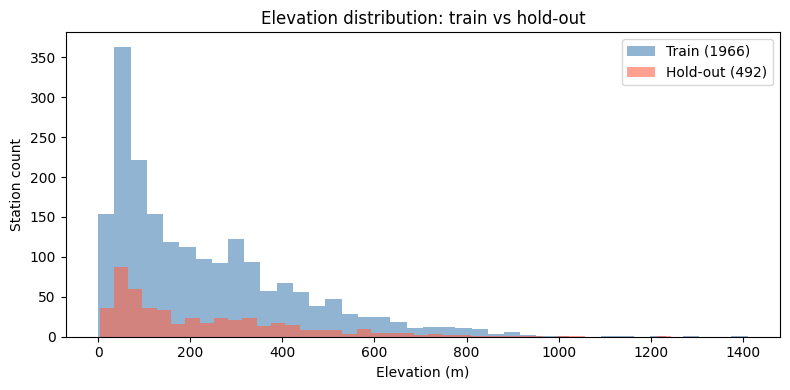

In [6]:
# Plot elevation distributions
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_meta['elevation_m'],   bins=40, alpha=0.6, label=f'Train ({len(train_ids)})',   color='steelblue')
ax.hist(holdout_meta['elevation_m'], bins=40, alpha=0.6, label=f'Hold-out ({len(holdout_ids)})', color='tomato')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Station count')
ax.set_title('Elevation distribution: train vs hold-out')
ax.legend()
fig.tight_layout()
plt.show()

## Next Steps

1. **Commit** `outputs/holdout_station_ids.json` to git — never regenerate it
2. All calls to `registry.stations.load()` now automatically exclude hold-out stations
3. For **final evaluation only**: call `registry.stations.load(..., exclude_holdout=False)` and filter to hold-out IDs